In [1]:
import os
import pickle
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Root directory for all results
BASE_DIR = Path("./results/nonsmooth_nonconvex/socp/SOCPProblem-100-50-50-10000")


In [2]:
main_result_path = {
    "vanilla":
    [
        "20260115-012027_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000",
        # "20260115-013345_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000",
        "20260115-012025_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000",
        "20260115-013254_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000",
    ],
    "pretraining":
    [
        "20260115-184556_MLP_sup_pen_seed0_nepochs1000_lr0.0001_trainsize7000_subopt_3_3.0",
    ],
    'warm-started':
    [
        "20260117-185928_MLP_FSNet_seed0_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
        # "20260117-185930_MLP_FSNet_seed2_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
        "20260117-191324_MLP_FSNet_seed1_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
        "20260117-191337_MLP_FSNet_seed3_nepochs300_lr0.0001_trainsize7000_finetune_20260115-184556_sup_seedpen_model_150",
    ], # 3.0
}

In [3]:
# --- Functions ---
def load_results(path):
    with open(path, 'rb') as f:
        return pickle.load(f)

def get_metrics(results, history_key='val_history'):
    if history_key not in results or not results[history_key]:
        return None
    metrics = {k: [] for k in results[history_key][0].keys()}
    for entry in results[history_key]:
        for key in metrics.keys():
            metrics[key].append(entry[key])
    return {k: np.array(v) for k, v in metrics.items()}

def load_and_recompute(result_paths, base_path):
    data_tree = {}
    for method, folders in result_paths.items():
        data_tree[method] = []
        for folder in folders:
            p = base_path / folder / "results.pkl"
            if p.exists():
                res = load_results(p)
                m = get_metrics(res, 'val_history')
                eq_weight = 1e5
                ineq_weight = 1e5   
                
                # Recompute Merit Mean using requested keys
                m['recomputed_merit_mean'] = (
                    m['objective'] + 
                    eq_weight * m['eq_violation_l1_mean'] + ineq_weight * m['ineq_violation_l1_mean']
                )
                
                m['recomputed_merit_max'] = (
                    m['objective_max'] + 
                    eq_weight * m['eq_violation_l1_max'] + ineq_weight * m['ineq_violation_l1_max']
                )
                
                data_tree[method].append(m)
            else:
                print(f"Warning: Path not found {p}")
    return data_tree

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import ScalarFormatter

SKIP = 1 # skip_first
LINE_WIDTH = 3
BASE_SIZE = 24
# Professional colors
COLORS = {'vanilla': "#E6675E", 'pretraining': "#4D8CDF", 'warm-started': "#2CA523"}

def plot_learning_dual_axis(data_tree, metric_name='recomputed_merit_mean'):
    # Reduced base font size for a cleaner look
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # --- Left Axis: Vanilla and warm-started ---
    ax1.set_xlabel('epoch', fontsize=BASE_SIZE)
    ax1.set_ylabel('vanilla & warm-started', fontsize=BASE_SIZE)

    # --- Annotation Logic ---
    ax1.axvline(x=300, color=COLORS['vanilla'], linestyle='--', linewidth=3, alpha=0.7)
    ax1.text(310, data_tree['vanilla'][0]['recomputed_merit_mean'][0] * 1.5, 'start SSL', fontsize=BASE_SIZE-8, verticalalignment='top', color=COLORS['vanilla'], alpha=1.0, fontweight='bold')

    methods_to_plot = {
        'vanilla': 'vanilla', 
        'warm-started': 'warm-started'
    }

    for label, key in methods_to_plot.items():
        if key in data_tree and data_tree[key]:
            runs = data_tree[key]
            # SHIFT LOGIC: Add 300 to the epoch array
            epochs = np.array(runs[0]['epoch'][0:]) + 300
            vals = np.mean([run[metric_name][0:] for run in runs], axis=0)
            
            ax1.plot(epochs, vals, label=label, color=COLORS[key], linewidth=LINE_WIDTH * 1.1)
            
            if len(runs) > 1:
                std = np.std([run[metric_name][0:] for run in runs], axis=0)
                ax1.fill_between(epochs, vals - std, vals + std, color=COLORS[key], alpha=0.15)

    for spine in ax1.spines.values():
        spine.set_linewidth(LINE_WIDTH)
        spine.set_color('black')

    ax1.set_ylim(-10, 80)
    ax1.set_xlim(0, 700)
    ax1.set_xticks([0, 200, 300, 400, 600])
    ax1.locator_params(axis='y', nbins=4)
    ax1.locator_params(axis='x', nbins=6)
    ax1.set_facecolor("white")
    ax1.tick_params(axis='y', labelsize=BASE_SIZE-4, width=LINE_WIDTH, length=8, color='black')
    ax1.tick_params(axis='x', labelsize=BASE_SIZE-4, width=LINE_WIDTH, length=8, color='black')
    ax1.set_title("average merit", fontsize=BASE_SIZE+4, pad=15)

    # --- Right Axis: Pretraining ---
    if 'pretraining' in data_tree and data_tree['pretraining']:
        ax2 = ax1.twinx()
        ax2.set_ylabel('pretraining', fontsize=BASE_SIZE, color=COLORS['pretraining'])
        
        runs = data_tree['pretraining']
        epochs = np.array(runs[0]['epoch'][SKIP:])
        vals = np.mean([run[metric_name][SKIP:] for run in runs], axis=0)
        
        ax2.plot(epochs, vals, label='pretraining', color=COLORS['pretraining'], linewidth=LINE_WIDTH * 1.1)
        
        if len(runs) > 1:
            std = np.std([run[metric_name][SKIP:] for run in runs], axis=0)
            ax2.fill_between(epochs, vals - std, vals + std, color=COLORS['pretraining'], alpha=0.15)
            
        ax2.tick_params(axis='y', labelsize=BASE_SIZE-4, width=LINE_WIDTH, length=8, color='black', labelcolor=COLORS['pretraining'])
        ax2.spines['top'].set_visible(False)

        # --- SHIFT LOGIC (Vertical) ---
        data_min = np.min(vals)
        data_max = np.max(vals)
        ax2.set_ylim(data_min * 0, data_max * 0.1)
        ax2.locator_params(axis='y', nbins=4)

        # SET POSITION OF 1e6 (Offset Text)
        formatter = ScalarFormatter(useMathText=True)
        formatter.set_scientific(True)
        formatter.set_powerlimits((5, 5)) # Force 10^5
        ax2.yaxis.set_major_formatter(formatter)
        ax2.yaxis.get_offset_text().set_fontsize(BASE_SIZE-6)
        ax2.yaxis.get_offset_text().set_position((1.02, 1)) 

        lines1, labels1 = ax1.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        # Smaller legend font
        ax1.legend(lines1 + lines2, labels1 + labels2, frameon=True, loc='lower left', fontsize=BASE_SIZE-6)
    else:
        ax1.legend(frameon=True, loc='lower left', fontsize=BASE_SIZE-6)

    plt.tight_layout()
    plt.show()

In [5]:
processed_data = load_and_recompute(main_result_path, BASE_DIR)

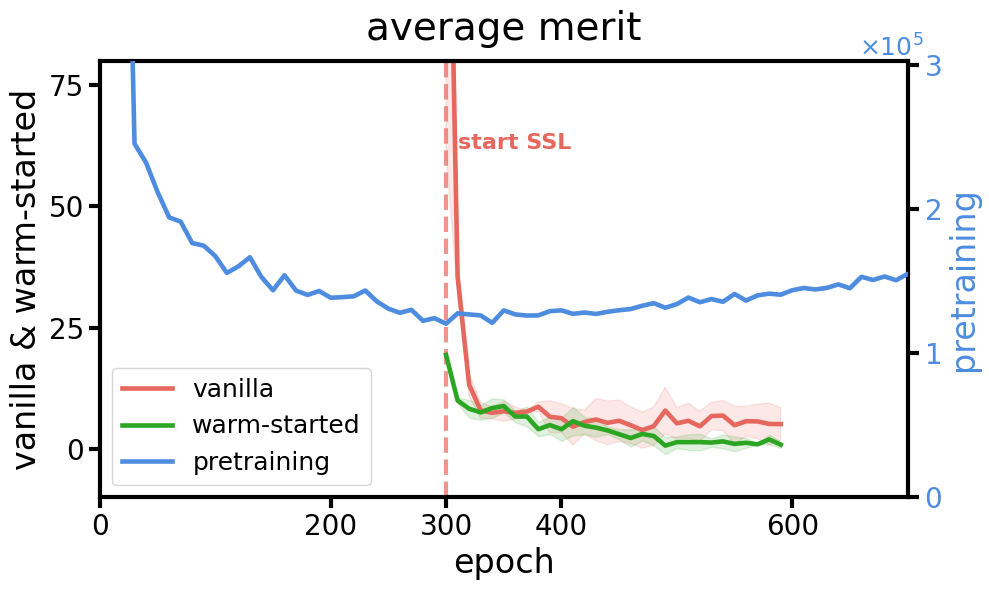

In [6]:
plot_learning_dual_axis(processed_data)